# Лабораторная работа №2: Корреляционный анализ

## Задание 1.3.1

**Условие задачи:**

Создайте два массива:
- `a = [10, 20, 30, 40, 50]`
- `b = [5, 15, 25, 35, 45]`

Вычислите корреляцию Пирсона **вручную** (используя формулу с ковариацией и стандартными отклонениями) и с помощью **NumPy**. Сравните результаты, визуализируйте данные и объясните, почему корреляция такая.

### Формула:
$r_{xy} = \frac{cov(X, Y)}{\sigma_X \cdot \sigma_Y}$

Где:

**Выборочная ковариация:**
$cov(X,Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$

**Выборочное стандартное отклонение:**
$\sigma_X = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}$


In [39]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([10, 20, 30, 40, 50])
b = np.array([5, 15, 25, 35, 45])

print("Массив a:", a)
print("Массив b:", b)

Массив a: [10 20 30 40 50]
Массив b: [ 5 15 25 35 45]


### Ручной расчет коэффициента корреляции Пирсона

In [9]:
# Шаг 1: Вычисление средних арифметических
mean_a = np.mean(a)
mean_b = np.mean(b)

print(f"Среднее значение a (x̄) = {mean_a}")
print(f"Среднее значение b (ȳ) = {mean_b}")

Среднее значение a (x̄) = 30.0
Среднее значение b (ȳ) = 25.0


In [11]:
# Шаг 2: Вычисление отклонений от средних
deviation_a = a - mean_a
deviation_b = b - mean_b

print("Отклонения a от среднего (x_i - x̄):", deviation_a)
print("Отклонения b от среднего (y_i - ȳ):", deviation_b)

# Проверка: сумма отклонений должна быть равна 0
print(f"\nПроверка: сумма отклонений a = {np.sum(deviation_a):.10f}")
print(f"Проверка: сумма отклонений b = {np.sum(deviation_b):.10f}")

Отклонения a от среднего (x_i - x̄): [-20. -10.   0.  10.  20.]
Отклонения b от среднего (y_i - ȳ): [-20. -10.   0.  10.  20.]

Проверка: сумма отклонений a = 0.0000000000
Проверка: сумма отклонений b = 0.0000000000


In [13]:
# Шаг 3: Вычисление произведений отклонений
product_deviations = deviation_a * deviation_b
print("Произведения отклонений (x_i - x̄)(y_i - ȳ):", product_deviations)

# Сумма произведений отклонений
sum_product_deviations = np.sum(product_deviations)
print(f"Сумма произведений отклонений = {sum_product_deviations}")

# Выборочная ковариация (делим на n-1)
n = len(a)
cov_manual = sum_product_deviations / (n - 1)
print(f"\nВыборочная ковариация cov(a,b) = {sum_product_deviations} / {n-1} = {cov_manual}")

Произведения отклонений (x_i - x̄)(y_i - ȳ): [400. 100.   0. 100. 400.]
Сумма произведений отклонений = 1000.0

Выборочная ковариация cov(a,b) = 1000.0 / 4 = 250.0


In [15]:
# Шаг 4: Вычисление дисперсий и стандартных отклонений

# Квадраты отклонений
squared_deviation_a = deviation_a ** 2
squared_deviation_b = deviation_b ** 2

print("Квадраты отклонений a:", squared_deviation_a)
print("Квадраты отклонений b:", squared_deviation_b)

# Суммы квадратов отклонений
sum_squared_a = np.sum(squared_deviation_a)
sum_squared_b = np.sum(squared_deviation_b)
print(f"\nСумма квадратов отклонений a = {sum_squared_a}")
print(f"Сумма квадратов отклонений b = {sum_squared_b}")

# Выборочная дисперсия
var_a = sum_squared_a / (n - 1)
var_b = sum_squared_b / (n - 1)
print(f"\nВыборочная дисперсия a = {sum_squared_a} / {n-1} = {var_a}")
print(f"Выборочная дисперсия b = {sum_squared_b} / {n-1} = {var_b}")

# Стандартные отклонения
std_a_manual = np.sqrt(var_a)
std_b_manual = np.sqrt(var_b)
print(f"\nСтандартное отклонение σ_a = √{var_a} = {std_a_manual:.4f}")
print(f"Стандартное отклонение σ_b = √{var_b} = {std_b_manual:.4f}")

Квадраты отклонений a: [400. 100.   0. 100. 400.]
Квадраты отклонений b: [400. 100.   0. 100. 400.]

Сумма квадратов отклонений a = 1000.0
Сумма квадратов отклонений b = 1000.0

Выборочная дисперсия a = 1000.0 / 4 = 250.0
Выборочная дисперсия b = 1000.0 / 4 = 250.0

Стандартное отклонение σ_a = √250.0 = 15.8114
Стандартное отклонение σ_b = √250.0 = 15.8114


In [19]:
# Шаг 5: Финальный расчет коэффициента корреляции

r_manual = cov_manual / (std_a_manual * std_b_manual)

print(f"r = cov(a,b) / (σ_a × σ_b)")
print(f"r = {cov_manual} / ({std_a_manual:.4f} × {std_b_manual:.4f})")
print(f"r = {cov_manual} / {std_a_manual * std_b_manual:.4f}")
print(f"\nКоэффициент корреляции Пирсона = {r_manual}")

r = cov(a,b) / (σ_a × σ_b)
r = 250.0 / (15.8114 × 15.8114)
r = 250.0 / 250.0000

Коэффициент корреляции Пирсона = 1.0


### Расчет с помощью NumPy для проверки

In [30]:
# Расчет с помощью NumPy
corr_matrix = np.corrcoef(a, b)
r_numpy = corr_matrix[0, 1]

print("Матрица корреляции:")
print(corr_matrix)
print(f"\nКоэффициент корреляции Пирсона = {r_numpy}")

# Сравнение результатов
print(f"Ручной расчет: {r_manual}")
print(f"NumPy расчет:  {r_numpy}")

Матрица корреляции:
[[1. 1.]
 [1. 1.]]

Коэффициент корреляции Пирсона = 1.0
Ручной расчет: 1.0
NumPy расчет:  1.0


### Интерпретация результатов

Коэффициент корреляции Пирсона: **1.0**

#### Пояснение:
Полученный коэффициент корреляции равен 1.0, что означает идеальную положительную линейную зависимость между массивами `a` и `b`.

1. Данные связаны точным линейным уравнением: $b = a - 5$
   - $5 = 10 - 5$ 
   - $15 = 20 - 5$ 
   - $25 = 30 - 5$ 
   - $35 = 40 - 5$ 
   - $45 = 50 - 5$ 

2. Геометрический смысл: все точки лежат строго на одной прямой, без каких-либо отклонений

### Визуализация данных

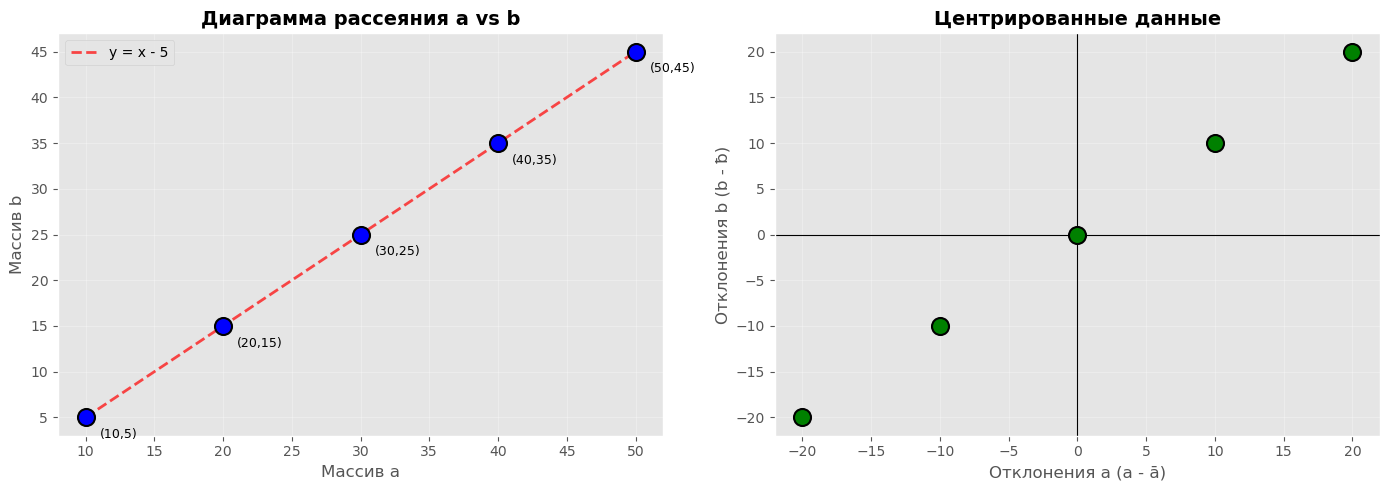

In [43]:
# Создание графика
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Точки данных
ax[0].scatter(a, b, color='blue', s=150, zorder=5, edgecolors='black', linewidth=1.5)
ax[0].plot(a, a - 5, 'r--', linewidth=2, label='y = x - 5', alpha=0.7)
ax[0].set_xlabel('Массив a', fontsize=12)
ax[0].set_ylabel('Массив b', fontsize=12)
ax[0].set_title('Диаграмма рассеяния a vs b', fontsize=14, fontweight='bold')
ax[0].legend(fontsize=10)
ax[0].grid(True, alpha=0.3)

# Добавление аннотаций с координатами точек
for i, (x_val, y_val) in enumerate(zip(a, b)):
    ax[0].annotate(f'({x_val},{y_val})', (x_val, y_val), 
                   textcoords="offset points", xytext=(10, -15), fontsize=9)

# График 2: Отклонения от средних
ax[1].scatter(deviation_a, deviation_b, color='green', s=150, zorder=5, edgecolors='black', linewidth=1.5)
ax[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax[1].set_xlabel('Отклонения a (a - ā)', fontsize=12)
ax[1].set_ylabel('Отклонения b (b - ƀ)', fontsize=12)
ax[1].set_title('Центрированные данные', fontsize=14, fontweight='bold')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 1.3.2

**Условие задачи:**

Для смоделированных данных с шумом: `x = np.arange(10)`, `y = 2*x + np.random.normal(0, 1, 10)`. Вычислите корреляцию и интерпретируйте.

Массив x: [0 1 2 3 4 5 6 7 8 9]
Сгенерированный массив y: [ 0.497  1.862  4.648  7.523  7.766  9.766 13.579 14.767 15.531 18.543]
Коэффициент корреляции Пирсона: 0.9929
p-value: 0.0000


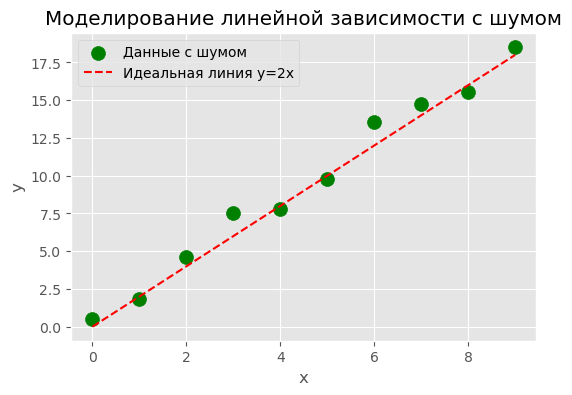

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Генерация данных с шумом
np.random.seed(42) # для воспроизводимости результатов
x = np.arange(10) # [0, 1, 2, ..., 9]
noise = np.random.normal(0, 1, 10) # шум со средним 0 и стд откл 1
y = 2 * x + noise

print("Массив x:", x)
print("Сгенерированный массив y:", np.round(y, 3))

# 2. Вычисление корреляции
corr, p_value = pearsonr(x, y)
print(f"Коэффициент корреляции Пирсона: {corr:.4f}")
print(f"p-value: {p_value:.4f}")

# 3. Визуализация
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='green', s=100, label='Данные с шумом')
# Построим идеальную линию 2x для сравнения
plt.plot(x, 2*x, color='red', linestyle='--', label='Идеальная линия y=2x')
plt.title('Моделирование линейной зависимости с шумом')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

### Интерпретация результатов

#### Исходные данные

| Переменная | Значения |
|------------|----------|
| **x** | `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]` |
| **y** | `[0.497, 1.862, 4.648, 7.523, 7.766, 9.766, 13.579, 14.767, 15.531, 18.543]` |

Модель генерации данных: $y = 2x + \varepsilon$, где $\varepsilon \sim \mathcal{N}(0, 1)$

---

#### Результаты статистического анализа

| Показатель | Значение |
|------------|----------|
| **Коэффициент корреляции Пирсона (r)** | **0.9929** |
| **p-value** | **≈ 0.0000** (менее $2.2 \times 10^{-9}$) |
| Количество наблюдений (n) | 10 |
| Степени свободы (df) | 8 |

---

#### Интерпретация коэффициента корреляции

Коэффициент корреляции Пирсона $r = 0.9929$ указывает на чрезвычайно сильную положительную линейную связь между переменными $x$ и $y$.

Что означает значение $r = 0.9929$:

1. **Направление связи:** Положительное значение $r$ говорит о том, что с увеличением $x$ значения $y$ также возрастают. Это соответствует заложенной в модель формуле $y = 2x$.

2. **Сила связи:** Значение $0.9929$ находится в диапазоне $0.9 < |r| \leq 1.0$, что по шкале Чеддока характеризуется как "весьма высокая" (практически функциональная) связь.

3. **Коэффициент детерминации:** $R^2 = r^2 = 0.9929^2 \approx 0.9859$ означает, что:
   - **98.59%** вариации (изменчивости) переменной $y$ объясняется изменениями переменной $x$
   - Только **1.41%** вариации $y$ обусловлен случайным шумом $\varepsilon$ и другими факторами

4. **Сравнение с идеальной моделью:** Исходная модель $y = 2x$ без шума дала бы $r = 1.0000$. Добавление нормального шума с $\sigma = 1$ снизило корреляцию всего на 0.0071

---

### Интерпретация p-value

**$p\text{-value} \approx 0.0000$** (фактически стремится к нулю, $p < 2.2 \times 10^{-9}$)

Проверяемая статистическая гипотеза:

$$
\begin{aligned}
H_0&: \rho = 0 \quad \text{(корреляция в генеральной совокупности отсутствует)} \\
H_1&: \rho \neq 0 \quad \text{(корреляция статистически значима)}
\end{aligned}
$$

**Вывод по гипотезе:**

- Заданный уровень значимости: $\alpha = 0.05$ (стандартный)
- $p\text{-value} \approx 0.0000 < 0.05$
- Нулевая гипотеза $H_0$ отвергается

Это означает, что вероятность случайно получить такое значение корреляции ($r = 0.9929$) при реальном отсутствии связи ($\rho = 0$) практически равна нулю.

## Задание 1.3.3

**Условие задачи:**

Требуется исследовать степень взаимосвязи между двумя 
признаками некоторых объектов. Необходимо выполнить задания для 
своего варианта (варианты заданий представлены в приложении) 
1. Визуализировать данные на плоскости в виде точек 
2. Статистически оценить коэффициент корреляции Пирсона 
между признаками $x$ и $y$ 
3. Проверить статистическую гипотезу о некоррелированности 
признаков $x$ и $y$ на уровне значимости 0,05.

### Вариант 25

### Student Performance (Успеваемость студентов)

**Признаки для анализа:**
- **G1** (столбец №31) — оценка за первый учебный период
- **G3** (столбец №33) — итоговая оценка за курс

**Цель:** выяснить, насколько сильно оценка в начале обучения связана с итоговым результатом.

In [60]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os

# Настройка графиков
plt.rcParams['figure.figsize'] = (8, 6)
plt.style.use('ggplot')

# Скачиваем ZIP-архив
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
urllib.request.urlretrieve(url, 'student.zip')

# Распаковываем архив
with zipfile.ZipFile('student.zip', 'r') as z:
    z.extractall('student_data')

# Читаем нужный CSV-файл
df = pd.read_csv('student_data/student-mat.csv', sep=';')
print("\nНазвания столбцов (первые 5 и последние 5):")
print(df.columns[:5].tolist(), "...", df.columns[-5:].tolist())

# Выбираем нужные столбцы G1 и G3
x = df['G1']  # оценка за первый период
y = df['G3']  # итоговая оценка

# Просмотр данных
print("\nПервые 10 строк:")
print(pd.DataFrame({
    'G1 (оценка за 1 период)': x.head(10).values, 
    'G3 (итоговая оценка)': y.head(10).values
}))


Названия столбцов (первые 5 и последние 5):
['school', 'sex', 'age', 'address', 'famsize'] ... ['health', 'absences', 'G1', 'G2', 'G3']

Первые 10 строк:
   G1 (оценка за 1 период)  G3 (итоговая оценка)
0                        5                     6
1                        5                     6
2                        7                    10
3                       15                    15
4                        6                    10
5                       15                    15
6                       12                    11
7                        6                     6
8                       16                    19
9                       14                    15


### Визуализация

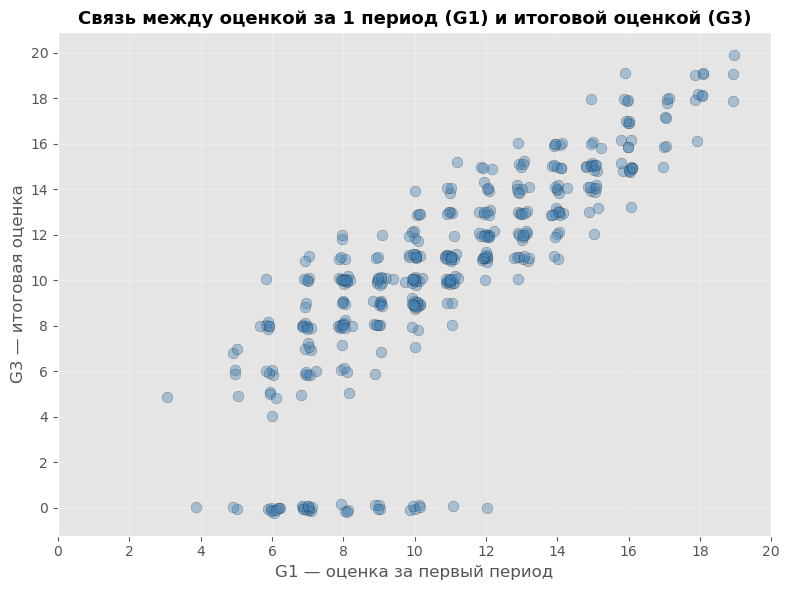

In [62]:
# Построение диаграммы рассеяния
plt.figure(figsize=(8, 6))

# Чтобы точки не накладывались друг на друга, добавим небольшой шум
jitter_x = x + np.random.normal(0, 0.1, len(x))
jitter_y = y + np.random.normal(0, 0.1, len(y))

plt.scatter(jitter_x, jitter_y, alpha=0.4, c='steelblue', edgecolors='black', linewidth=0.3, s=60)

# Настройка графика
plt.title('Связь между оценкой за 1 период (G1) и итоговой оценкой (G3)', fontsize=13, fontweight='bold')
plt.xlabel('G1 — оценка за первый период', fontsize=12)
plt.ylabel('G3 — итоговая оценка', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 21, 2))
plt.yticks(range(0, 21, 2))

plt.tight_layout()
plt.show()

### Расчет корреляции и проверка гипотезы

In [68]:
# Удаляем пропуски (если есть)
mask = x.notna() & y.notna()
x_clean = x[mask]
y_clean = y[mask]

# Вычисляем корреляцию Пирсона
r, p_value = pearsonr(x_clean, y_clean)

# Вывод результатов
print("   РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА")
print(f"  Количество наблюдений:        {len(x_clean)}")
print(f"  Коэффициент корреляции r:     {r:.6f}")
print(f"  Коэффициент детерминации R²:  {r**2:.4f}  ({r**2*100:.1f}%)")
print(f"  p-value:                      {p_value:.6e}")
print()

# Проверка гипотезы
alpha = 0.05
print("   ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ")
print(f"  Уровень значимости α:         {alpha}")
print()
print("  Н₀: корреляция отсутствует (ρ = 0)")
print("  Н₁: корреляция статистически значима (ρ ≠ 0)")
print()

if p_value < alpha:
    print(f"  p-value ({p_value:.2e}) < α ({alpha})")
    print(f"  Нулевая гипотеза отвергается: корреляция статистически значима")
else:
    print(f"  p-value ({p_value:.2e}) > α ({alpha})")
    print(f"  Нет оснований отвергнуть нулевую гипотезу")

   РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА
  Количество наблюдений:        395
  Коэффициент корреляции r:     0.801468
  Коэффициент детерминации R²:  0.6424  (64.2%)
  p-value:                      9.001430e-90

   ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ
  Уровень значимости α:         0.05

  Н₀: корреляция отсутствует (ρ = 0)
  Н₁: корреляция статистически значима (ρ ≠ 0)

  p-value (9.00e-90) < α (0.05)
  Нулевая гипотеза отвергается: корреляция статистически значима


### Интерпретация результатов

**Коэффициент корреляции r = 0.80**

Это значит:

- **Связь сильная.** Оценка в начале года и итоговая оценка заметно связаны между собой
- **Связь положительная.** Чем выше балл в первом периоде, тем выше итоговый результат
- **Связь не идеальная.** Бывают студенты, которые подтянулись к концу года, и наоборот — те, кто сдал позиции

**Коэффициент детерминации R² = 0.64**

Это значит, что примерно **64% итоговой оценки** можно объяснить тем, как студент учился в начале. Остальные **36%** зависят от других факторов: мотивации, сложности программы, помощи преподавателей, личных обстоятельств.

---

#### Насколько результату можно верить?

**p-value = 0.000...**

Это практически ноль. Вероятность, что такая сильная связь получилась случайно практически нулевая. Результат статистически значим.

---

#### Вывод

Оценка в начале года — это хороший предсказатель итогового результата. Студенты, которые с самого начала показывают высокие результаты, скорее всего, закончат год с хорошими оценками. Но примерно треть итогового балла зависит от других причин — поэтому всегда есть шанс улучшить свой результат к концу года.


In [72]:
# Удаляем скачанные файлы
import os
import shutil

if os.path.exists('student.zip'):
    os.remove('student.zip')
if os.path.exists('student_data'):
    shutil.rmtree('student_data')